In [2]:
import kagglehub

path = kagglehub.dataset_download("naserabdullahalam/phishing-email-dataset")
print(path)

import os
for f in os.listdir(path):
    print(f)

/kaggle/input/datasets/naserabdullahalam/phishing-email-dataset
SpamAssasin.csv
Nazario.csv
Nigerian_Fraud.csv
CEAS_08.csv
Enron.csv
Ling.csv
phishing_email.csv


In [3]:
import torch
print(torch.cuda.device_count())

2


In [4]:
file_paths = [os.path.join(path, file_name) for file_name in os.listdir(path)]

In [5]:
import pandas as pd
dfs = [pd.read_csv(file) for file in file_paths]

In [6]:
dataset = pd.concat(dfs, ignore_index=False)

In [7]:
dataset['combined_text'] = dataset['body'].fillna('') + ' ' + dataset['text_combined'].fillna('')
dataset['combined_text'] = dataset['combined_text'].str.strip()

In [8]:
dataset.isnull().sum()

sender           115443
receiver         117204
date             115595
subject           82833
body              82487
label                 0
urls             115112
text_combined     82486
combined_text         0
dtype: int64

In [9]:
dataset = dataset.drop_duplicates('combined_text')

In [10]:
dataset

,sender,receiver,date,subject,body,label,urls,text_combined,combined_text
0,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,"Thu, 22 Aug 2002 18:26:25 +0700",Re: New Sequences Window,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ...",0,1.0,NaN,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ..."
1,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...","Thu, 22 Aug 2002 12:46:18 +0100",[zzzzteana] RE: Alexander,"Martin A posted:\nTassos Papadopoulos, the Gre...",0,1.0,NaN,"Martin A posted:\nTassos Papadopoulos, the Gre..."
2,"""Tim Chapman"" <timc@2ubh.com>",zzzzteana <zzzzteana@yahoogroups.com>,"Thu, 22 Aug 2002 13:52:38 +0100",[zzzzteana] Moscow bomber,Man Threatens Explosion In Moscow \n\nThursday...,0,1.0,NaN,Man Threatens Explosion In Moscow \n\nThursday...
3,Monty Solomon <monty@roscom.com>,undisclosed-recipient: ;,"Thu, 22 Aug 2002 09:15:25 -0400",[IRR] Klez: The Virus That Won't Die,Klez: The Virus That Won't Die\n \nAlready the...,0,1.0,NaN,Klez: The Virus That Won't Die\n \nAlready the...
4,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:38:22 +0100",Re: [zzzzteana] Nothing like mama used to make,"> in adding cream to spaghetti carbonara, whi...",0,1.0,NaN,"> in adding cream to spaghetti carbonara, whi..."
...,...,...,...,...,...,...,...,...,...
82481,NaN,NaN,NaN,NaN,NaN,1,NaN,info advantageapartmentscom infoadvantageapart...,info advantageapartmentscom infoadvantageapart...
82482,NaN,NaN,NaN,NaN,NaN,1,NaN,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...
82483,NaN,NaN,NaN,NaN,NaN,1,NaN,help center infohelpcentercoza_infohelpcenterc...,help center infohelpcentercoza_infohelpcenterc...
82484,NaN,NaN,NaN,NaN,NaN,1,NaN,metamask infosofamekarcom verify metamask wall...,metamask infosofamekarcom verify metamask wall...


In [11]:
data = dataset[['combined_text', 'label']]
data = data.reset_index(drop=True)
data

,combined_text,label
0,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ...",0
1,"Martin A posted:\nTassos Papadopoulos, the Gre...",0
2,Man Threatens Explosion In Moscow \n\nThursday...,0
3,Klez: The Virus That Won't Die\n \nAlready the...,0
4,"> in adding cream to spaghetti carbonara, whi...",0
...,...,...
163864,info advantageapartmentscom infoadvantageapart...,1
163865,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...,1
163866,help center infohelpcentercoza_infohelpcenterc...,1
163867,metamask infosofamekarcom verify metamask wall...,1


In [12]:
Test_size=0.2
Seed=1

In [13]:
from sklearn.model_selection import train_test_split
data = data.sample(50000)
train, test = train_test_split(data,test_size=Test_size, random_state=Seed,stratify=data['label'])

In [14]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [15]:
model_name = "bert-base-uncased"
MAX_LEN = 512
BATCH_SIZE = 32
Epochs = 5
LR = 1e-5
output_dir = "./bert-sentiment"

In [16]:
from datasets import Dataset
from transformers import BertTokenizerFast, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

tokenizer = BertTokenizerFast.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [17]:
def tokenize(batch):
    return tokenizer(batch['combined_text'], truncation=True, padding='max_length', max_length=512)

train_ds = Dataset.from_pandas(train.reset_index(drop=True))
train_ds = train_ds.map(tokenize, batched=True)
train_ds = train_ds.remove_columns(['combined_text']) 
train_ds = train_ds.rename_column('label', 'labels')

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

In [18]:
print(len(train_ds[0]['input_ids']))
print(len(train_ds[1]['input_ids']))
train_ds

512
512


Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 40000
})

In [19]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds)
    }

test_ds = Dataset.from_pandas(test.reset_index(drop=True))
test_ds = test_ds.map(tokenize,batched=True)
test_ds = test_ds.remove_columns(['combined_text'])
test_ds = test_ds.rename_column('label', 'labels')

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [20]:
from transformers import DataCollatorWithPadding
import torch.nn as nn
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(model_name,num_labels=2,attn_implementation="sdpa")
#model = nn.DataParallel(model)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
# training_args = TrainingArguments(
#     output_dir=output_dir,
#     num_train_epochs=Epochs,
#     per_device_train_batch_size=BATCH_SIZE,
#     per_device_eval_batch_size=BATCH_SIZE,
#     learning_rate=1e-5,
#   warmup_ratio=0.1,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     gradient_accumulation_steps=1,
#     #gradient_checkpointing=True,
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     logging_strategy="epoch",
#     fp16=torch.cuda.is_available(),
#     optim="adamw_torch_fused",
#     remove_unused_columns=False,
#     ddp_find_unused_parameters=False, 
#     dataloader_num_workers=4,
#     dataloader_pin_memory=True,
#     seed=1,
#     report_to="none",
# )
training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=Epochs,
    
    # 32 per GPU stays safely within 16GB VRAM limits
    per_device_train_batch_size=32,   
    per_device_eval_batch_size=32,
    
    # Gradient accumulation of 4 lowers step count to achieve 8-minute epochs
    gradient_accumulation_steps=4,    
    
    learning_rate=2e-5,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    fp16=True,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    optim="adamw_torch_fused",
    logging_strategy="epoch",
    report_to="none",
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [22]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    data_collator = data_collator,
     callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

In [23]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.203694,0.169620,0.970600,0.971006
2,0.305088,0.067159,0.989500,0.989895
3,0.142324,0.057094,0.991900,0.992170
4,0.063717,0.072050,0.990900,0.991188
5,0.022117,0.074942,0.992000,0.992266


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=785, training_loss=0.5473882456493985, metrics={'train_runtime': 9853.4681, 'train_samples_per_second': 20.297, 'train_steps_per_second': 0.08, 'total_flos': 5.2622211072e+16, 'train_loss': 0.5473882456493985, 'epoch': 5.0})

In [24]:
test_ds

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10000
})

In [25]:
y_test = test['label'].to_numpy()
preds = trainer.predict(test_ds)
preds = np.argmax(preds.predictions,axis=-1)

acc = accuracy_score(y_test,preds)
conf_matrix = confusion_matrix(y_test,preds)
report = classification_report(y_test,preds)
print(report)

from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

print(classifier("Hi, this is Dan your"))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4827
           1       0.99      0.99      0.99      5173

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

[{'label': 'LABEL_0', 'score': 0.9863161444664001}]


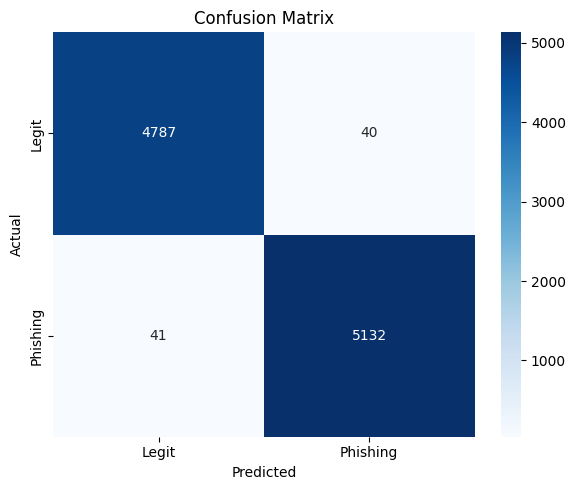

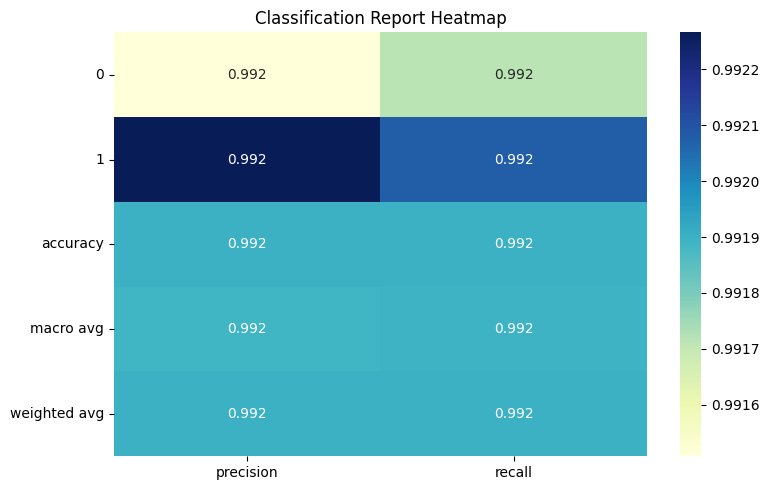

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# --- Confusion Matrix Heatmap ---
conf_matrix = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Phishing'],   # adjust labels to match your actual classes
            yticklabels=['Legit', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# --- Classification Report Heatmap ---
report_dict = classification_report(y_test, preds, output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T
# drops 'support' row from columns view issue; iloc[:-1,:] drops 'accuracy' row since it's a scalar, not per-class

plt.figure(figsize=(8, 5))
sns.heatmap(report_df.iloc[:, :-1], annot=True, cmap='YlGnBu', fmt='.3f')
# iloc[:, :-1] drops the 'support' column since it's a count, not a 0-1 metric, and would skew the color scale
plt.title('Classification Report Heatmap')
plt.tight_layout()
plt.show()

In [30]:
phishing_sample = """
Dear Customer,

We have detected unusual activity on your account. Your account has been temporarily
suspended for security reasons. To restore full access, please verify your identity
immediately by clicking the link below:

http://secure-bankverify-update.com/login

Failure to verify within 24 hours will result in permanent account closure.
This is an automated message, please do not reply.

Regards,
Security Team
"""

print(classifier(phishing_sample))

[{'label': 'LABEL_1', 'score': 0.9994872808456421}]


In [31]:
legit_sample = """
Hi team,

Just a reminder that our weekly sync is moved to 3pm tomorrow instead of 10am.
Please update your calendars accordingly. Let me know if this conflicts with
anything on your end.

Thanks,
Sarah
"""

print(classifier(legit_sample))

[{'label': 'LABEL_0', 'score': 0.9987688660621643}]


In [32]:
trainer.save_model("./phishing_model")
tokenizer.save_pretrained("./phishing_model")  # same folder, not a separate one

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./phishing_model/tokenizer_config.json', './phishing_model/tokenizer.json')

In [33]:
import shutil
shutil.make_archive("/kaggle/working/phishing_model", "zip", "./phishing_model")

'/kaggle/working/phishing_model.zip'

In [34]:
from IPython.display import FileLink
FileLink("/kaggle/working/phishing_model.zip")

/kaggle/working/phishing_model.zip

In [38]:
model.push_to_hub("mudassir032/PHISH_BERT")
tokenizer.push_to_hub("mudassir032/PHISH_BERT")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/mudassir032/PHISH_BERT/commit/ecb93820721d3d1befcc2a90ec1895de4016a1fb', commit_message='Upload tokenizer', commit_description='', oid='ecb93820721d3d1befcc2a90ec1895de4016a1fb', pr_url=None, repo_url=RepoUrl('https://huggingface.co/mudassir032/PHISH_BERT', endpoint='https://huggingface.co', repo_type='model', repo_id='mudassir032/PHISH_BERT'), pr_revision=None, pr_num=None)